In [1]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
#import scienceplots 

#plt.style.use(['science', 'notebook', 'grid'])

from scipy.special import lambertw

## COMPRESSOR

Original resistor values:

- R1 = 10k
- R2 = 62k
- R3 = 10k
- R4 = 90.9k
- R5 = 100k
- R6 = 200k
- R7 = 200k

In [2]:
# Original resistors:

R1_o = 10000
R2_o = 62000
R3_o = 10000
R4_o = 90900
R5_o = 100000
R6_o = 2 * R5_o
R7_o = 200000

# New resistors

R1_n = 20000
R2_n = 124000
R3_n = 10000
R4_n = 90900
R5_n = 100000
R6_n = 2 * R5_n
R7_n = 100000

44.40029225895805
22.200146129479027


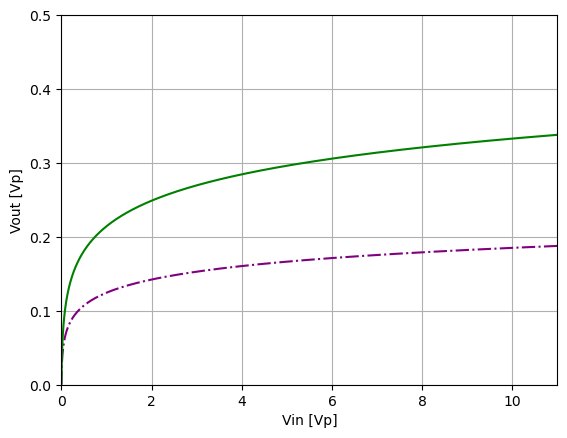

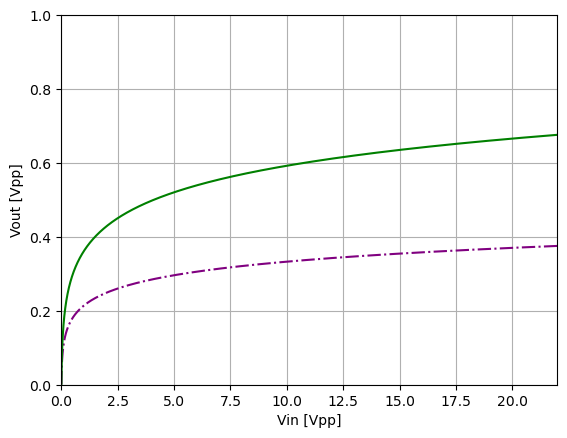

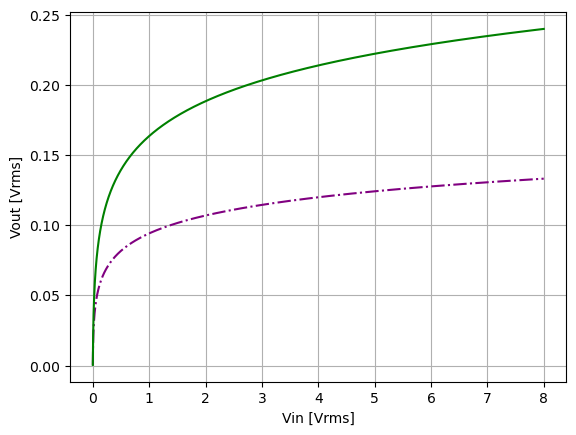

In [5]:
# Define Vin in RMS

Vin = np.linspace(0.00007746,8,100000)
#Vin = np.linspace(1,8,100000)

# Calculate Vout in RMS with original resistors:

u_o = (3/2)*(R7_o/R5_o)*(R4_o/R3_o)*(1/np.sqrt(2))*np.log(10)

print(u_o)

Vout_o = lambertw(u_o*(R2_o/R1_o)*Vin)/u_o

# Calculate Vout in RMS with new resistors:

u_n = (3/2)*(R7_n/R5_n)*(R4_n/R3_n)*(1/np.sqrt(2))*np.log(10)

print(u_n)

Vout_n = lambertw(u_n*(R2_n/R1_n)*Vin)/u_n



def rms2Vp(Vrms):
    return Vrms * np.sqrt(2)

def Vp2rms(Vp):
    return Vp / np.sqrt(2)

Vin_p = rms2Vp(Vin)
Vout_p_o = rms2Vp(Vout_o)
Vout_p_n = rms2Vp(Vout_n)

fig1 = plt.figure()
ax = fig1.add_subplot(1, 1, 1)
ax.plot(Vin_p, Vout_p_o, '-.', color='purple')
ax.plot(Vin_p, Vout_p_n, color='green')
ax.set_xlim(0, 11)
ax.set_ylim(0, 0.5)
plt.xlabel('Vin [Vp]')
plt.ylabel('Vout [Vp]')
plt.grid()

Vin_pp = Vin_p * 2
Vout_pp_o = Vout_p_o * 2
Vout_pp_n = Vout_p_n * 2

fig2 = plt.figure()
ax = fig2.add_subplot(1, 1, 1)
ax.plot(Vin_pp, Vout_pp_o, '-.', color='purple')
ax.plot(Vin_pp, Vout_pp_n, color='green')
ax.set_xlim(0, 22)
ax.set_ylim(0, 1)
plt.xlabel('Vin [Vpp]')
plt.ylabel('Vout [Vpp]')
plt.grid()


fig2rms = plt.figure()
ax = fig2rms.add_subplot(1, 1, 1)
ax.plot(Vin, Vout_o, '-.', color='purple')
ax.plot(Vin, Vout_n, color='green')
#ax.set_xlim(0, 22)
#ax.set_ylim(0, 1)
plt.xlabel('Vin [Vrms]')
plt.ylabel('Vout [Vrms]')
plt.grid()

Text(0, 0.5, 'Vout[p]')

C:\Users\rodri\AppData\Local\Temp\ipykernel_21016\1299715529.py:4: RuntimeWarning: divide by zero encountered in log10
,  return 20 * np.log10(Vrms/V0)


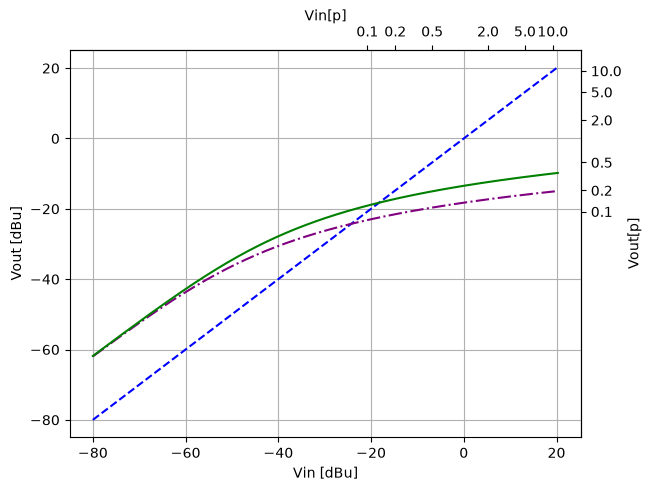

In [46]:
V0 = 0.7746

def rms2dBu(Vrms):
    return 20 * np.log10(Vrms/V0)

def dBu2rms(VdBu):
    return V0 * np.pow(10, VdBu/20)


def dBu2Vp(VdBu):
    return rms2Vp(dBu2rms(VdBu))

def Vp2dBu(Vp):
    return rms2dBu(Vp2rms(Vp))

Vin_dBu = rms2dBu(Vin)
Vout_dBu_o = rms2dBu(Vout_o)
Vout_dBu_n = rms2dBu(Vout_n)


fig3, ax1 = plt.subplots(layout='constrained')
#ax1 = fig3.add_subplot(1, 1, 1)
ax1.plot(Vin_dBu, Vin_dBu, '--', color='blue')
ax1.plot(Vin_dBu, Vout_dBu_o, '-.', color='purple')
ax1.plot(Vin_dBu, Vout_dBu_n, '-', color='green')
ax1.set_xlabel('Vin [dBu]')
ax1.set_ylabel('Vout [dBu]')
plt.grid(which='both')


#secax1 = ax1.secondary_xaxis('top', functions=(dBu2rms, rms2dBu))
secax1 = ax1.secondary_xaxis('top', functions=(dBu2Vp, Vp2dBu))
secax1.set_xticks([0.1, 0.2, 0.5, 2, 5, 10])
secax1.set_xlabel('Vin[p]')
secax1 = ax1.secondary_yaxis('right', functions=(dBu2Vp, Vp2dBu))
secax1.set_yticks([0.1, 0.2, 0.5, 2, 5, 10])
secax1.set_ylabel('Vout[p]')


C:\Users\rodri\AppData\Local\Temp\ipykernel_21016\1299715529.py:4: RuntimeWarning: divide by zero encountered in log10
,  return 20 * np.log10(Vrms/V0)


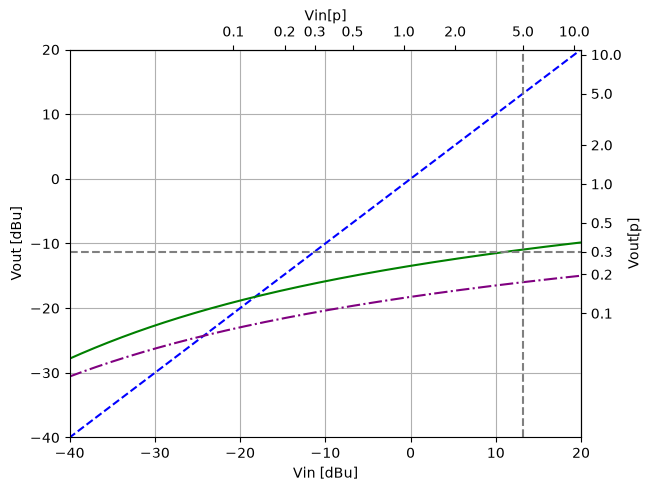

In [48]:
fig4, ax2 = plt.subplots(layout='constrained')
ax2.plot(Vin_dBu, Vin_dBu, '--', color='blue')
ax2.plot(Vin_dBu, Vout_dBu_o, '-.', color='purple')
ax2.plot(Vin_dBu, Vout_dBu_n, '-', color='green')
ax2.set_xlabel('Vin [dBu]')
ax2.set_ylabel('Vout [dBu]')
ax2.set_xlim(-40,20)
ax2.set_ylim(-40,20)
ax2.axvline(Vp2dBu(5), color='grey', ls='--')
ax2.axhline(Vp2dBu(0.3), color='grey', ls='--')

#secax2 = ax2.secondary_xaxis('top', functions=(dBu2rms, rms2dBu))
secax2 = ax2.secondary_xaxis('top', functions=(dBu2Vp, Vp2dBu))
secax2.set_xticks([0.1, 0.2, 0.3, 0.5, 1, 2, 5, 10])
secax2.set_xlabel('Vin[p]')
secax2 = ax2.secondary_yaxis('right', functions=(dBu2Vp, Vp2dBu))
secax2.set_yticks([0.1, 0.2, 0.3, 0.5, 1, 2, 5, 10])
secax2.set_ylabel('Vout[p]')
plt.grid(which='both')

## EXPANDER

19.282801922957148


Text(0, 0.5, 'Vout[p]')

C:\Users\rodri\AppData\Local\Temp\ipykernel_21016\1299715529.py:4: RuntimeWarning: divide by zero encountered in log10
,  return 20 * np.log10(Vrms/V0)


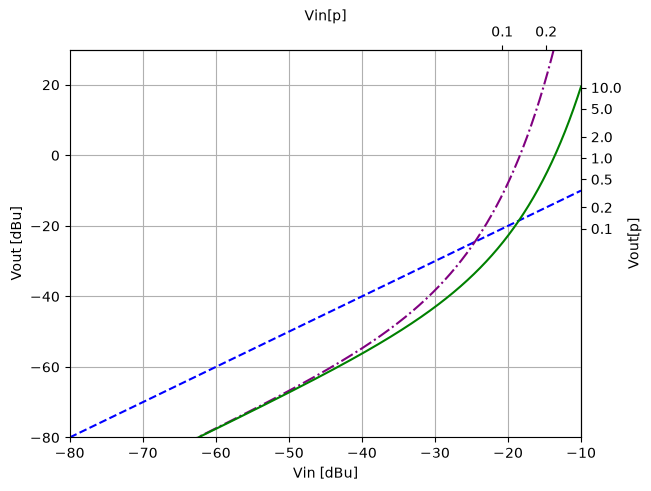

In [53]:
# Original resistors:

R1_o = 10000
R2_o = 82000
R3_o = 10000
R4_o = 90900
R5_o = 100000
R6_o = 2 * R5_o
R7_o = 200000

# New resistors

R1_n = 20000
R2_n = 164000
R3_n = 10000
R4_n = 90900
R5_n = 100000
R6_n = 2 * R5_n
R7_n = 100000

Vref = 0.6

# Define Vin in RMS

Vin = np.linspace(0.00007746,8,100000)
#Vin = np.linspace(1,8,100000)

# Calculate Vout in RMS with original resistors:

u_o = (3/2)*(R7_o/R5_o)*(R4_o/R3_o)*(1/np.sqrt(2))

print(u_o)

# Calculate Vout in RMS with new resistors:

u_n = (3/2)*(R7_n/R5_n)*(R4_n/R3_n)*(1/np.sqrt(2))

Vin_dBu = rms2dBu(Vin)

Vout_o = Vin * (R2_o/R1_o)*(1/np.pow(10, 3*Vref))*np.pow(10, u_o*Vin)

Vout_n = Vin * (R2_n/R1_n)*(1/np.pow(10, 3*Vref))*np.pow(10, u_n*Vin)

Vout_dBu_o = rms2dBu(Vout_o)
Vout_dBu_n = rms2dBu(Vout_n)


fig5, ax3 = plt.subplots(layout='constrained')
ax3.plot(Vin_dBu, Vin_dBu, '--', color='blue')
ax3.plot(Vin_dBu, Vout_dBu_o, '-.', color='purple')
ax3.plot(Vin_dBu, Vout_dBu_n, '-', color='green')
ax3.set_xlim(-80, -10)
ax3.set_ylim(-80, 30)
ax3.set_xlabel('Vin [dBu]')
ax3.set_ylabel('Vout [dBu]')
plt.grid(which='both')


#secax3 = ax3.secondary_xaxis('top', functions=(dBu2rms, rms2dBu))
secax3 = ax3.secondary_xaxis('top', functions=(dBu2Vp, Vp2dBu))
secax3.set_xticks([0.1, 0.2, 0.5, 1, 2, 5, 10])
secax3.set_xlabel('Vin[p]')
secax3 = ax3.secondary_yaxis('right', functions=(dBu2Vp, Vp2dBu))
secax3.set_yticks([0.1, 0.2, 0.5, 1, 2, 5, 10])
secax3.set_ylabel('Vout[p]')


C:\Users\rodri\AppData\Local\Temp\ipykernel_21016\1299715529.py:4: RuntimeWarning: divide by zero encountered in log10
,  return 20 * np.log10(Vrms/V0)


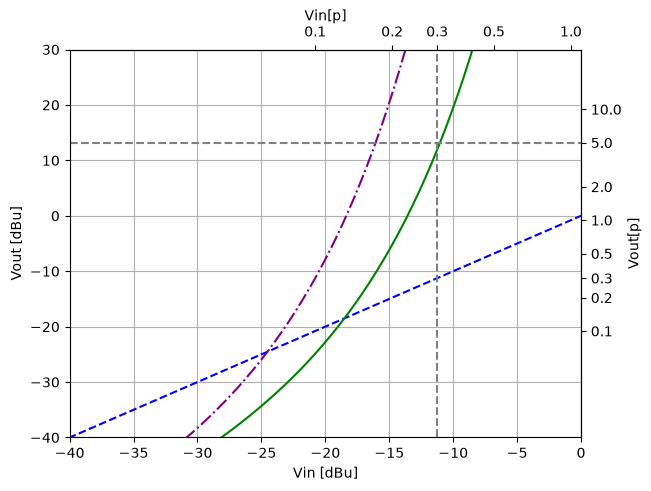

In [52]:

fig6, ax4 = plt.subplots(layout='constrained')
ax4.plot(Vin_dBu, Vin_dBu, '--', color='blue')
ax4.plot(Vin_dBu, Vout_dBu_o, '-.', color='purple')
ax4.plot(Vin_dBu, Vout_dBu_n, '-', color='green')
ax4.set_xlabel('Vin [dBu]')
ax4.set_ylabel('Vout [dBu]')
ax4.set_xlim(-40,0)
ax4.set_ylim(-40,30)
ax4.axvline(Vp2dBu(0.3), color='grey', ls='--')
ax4.axhline(Vp2dBu(5), color='grey', ls='--')

#secax4 = ax4.secondary_xaxis('top', functions=(dBu2rms, rms2dBu))
secax4 = ax4.secondary_xaxis('top', functions=(dBu2Vp, Vp2dBu))
secax4.set_xticks([0.1, 0.2, 0.3, 0.5, 1, 2, 5, 10])
secax4.set_xlabel('Vin[p]')
secax4 = ax4.secondary_yaxis('right', functions=(dBu2Vp, Vp2dBu))
secax4.set_yticks([0.1, 0.2, 0.3, 0.5, 1, 2, 5, 10])
secax4.set_ylabel('Vout[p]')
plt.grid(which='both')
